In [ ]:
Course-End Project: Marketing Campaigns
--------------------------------------------
Problem scenario:

Marketing mix stands as a widely utilized concept in the execution of marketing strategies.
It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing:
product, price, place, and promotion.

Problem objective:

As a data scientist, you must conduct exploratory data analysis and hypothesis testing to enhance your comprehension of 
the diverse factors influencing customer acquisition.

In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
# Step 2: Load Dataset
df = pd.read_csv("marketing_campaign_data.csv") # Update file path

In [13]:
# Step 3: Basic Exploration
print("First 5 Rows:")
print(df.head())

First 5 Rows:
         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0    342199        1985  Graduation       Together  59011.7        1   
1   8075450        1975      Master         Single   1730.0        1   
2  13664263        1978  Graduation        Married  98584.6        0   
3  16164787        1976  Graduation        Married  74031.5        1   
4  15815139        1981  Graduation       Divorced  52784.2        1   

   Teenhome Dt_Customer  Recency  MntWines  ...  NumStorePurchases  \
0         0  17-11-2012        3         0  ...                  3   
1         1  10-04-2013       96         0  ...                  2   
2         0  11-01-2014       99       920  ...                  6   
3         0  18-06-2014       47       265  ...                 11   
4         1  20-05-2014        0        30  ...                  3   

   NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  \
0                  4             0             0    

In [14]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    

In [7]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                 ID    Year_Birth         Income       Kidhome      Teenhome  \
count  5.600000e+04  56000.000000   56000.000000  56000.000000  56000.000000   
mean   8.389352e+06   1971.666696   57252.189521      0.539911      0.362143   
std    4.844638e+06     12.211066   34307.247999      0.521349      0.510567   
min    3.600000e+01   1936.000000    1730.000000      0.000000      0.000000   
25%    4.187372e+06   1963.000000   28252.025000      0.000000      0.000000   
50%    8.383784e+06   1973.000000   58838.550000      1.000000      0.000000   
75%    1.258576e+07   1981.000000   86930.650000      1.000000      1.000000   
max    1.677716e+07   1996.000000  258027.500000      2.000000      2.000000   

            Recency      MntWines     MntFruits  MntMeatProducts  \
count  56000.000000  56000.000000  56000.000000     56000.000000   
mean      63.221107    246.981482     16.152661       268.294018   
std       31.157066    358.569481     33.931463       

In [8]:
# Step 4: Data Cleaning
# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [9]:
# Create Age column
df['Age'] = 2026 - df['Year_Birth']

In [10]:
# Handle missing values
df = df.dropna()

In [11]:
# Step 5: Feature Engineering
# Total Spending
df['Total_Spending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                        df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])


In [12]:
# Total Purchases
df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'])

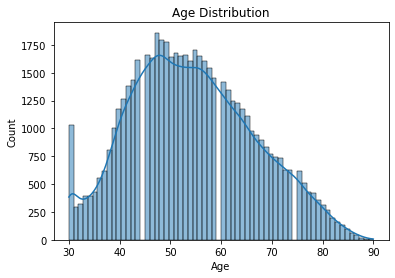

In [29]:
# Step 6: EDA - People (Demographics)
plt.figure()
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

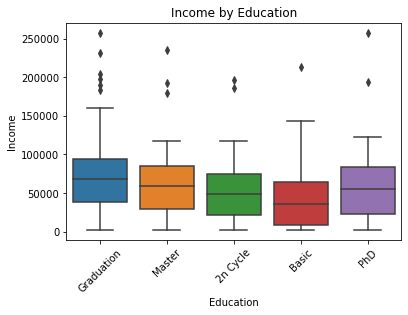

In [13]:
plt.figure()
sns.boxplot(x='Education', y='Income', data=df)
plt.title("Income by Education")
plt.xticks(rotation=45)
plt.show()

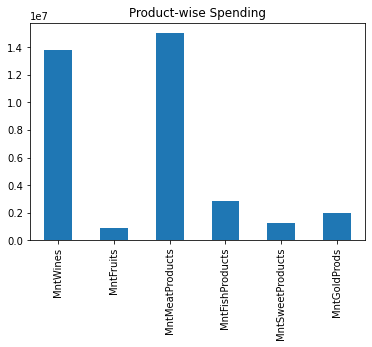

In [14]:
# 📌 Step 7: EDA - Product (Spending)
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df[product_cols].sum().plot(kind='bar')
plt.title("Product-wise Spending")
plt.show()

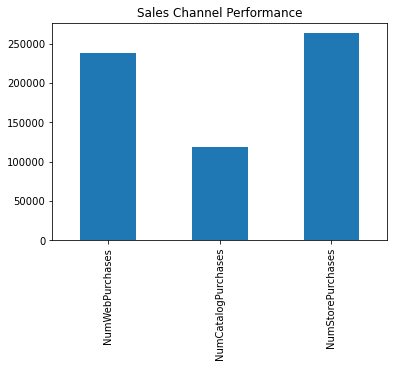

In [32]:
# 📌 Step 8: EDA - Place (Channels)
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df[channel_cols].sum().plot(kind='bar')
plt.title("Sales Channel Performance")
plt.show()

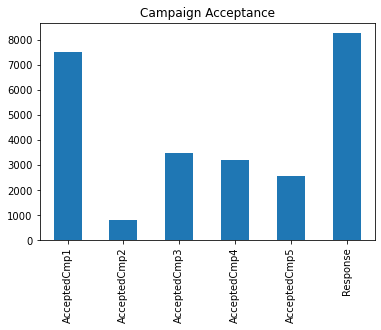

In [33]:
# 📌 Step 9: EDA - Promotion (Campaigns)
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

df[campaign_cols].sum().plot(kind='bar')
plt.title("Campaign Acceptance")
plt.show()

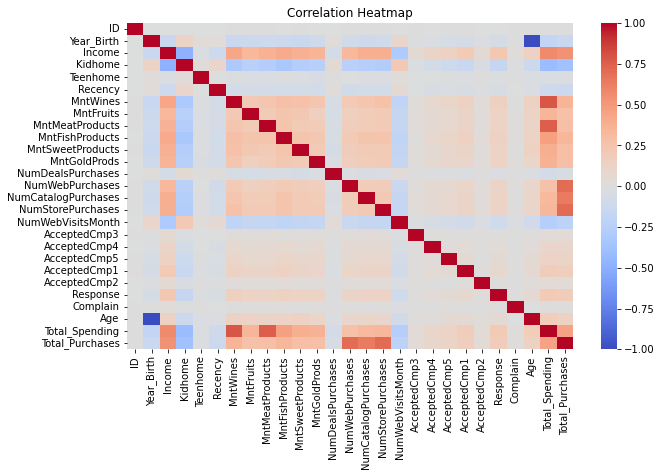

In [18]:
#Step 10: Correlation Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# Step 11: Hypothesis Testing

# Hypothesis 1:
# H0: Income has no impact on spending
# H1: Income impacts spending
#------------------------------------------------------
corr, p_value = stats.pearsonr(df['Income'], df['Total_Spending'])

print("\nHypothesis 1 (Income vs Spending):")
print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Income significantly affects spending")
else:
    print("Fail to Reject H0")


Hypothesis 1 (Income vs Spending):
Correlation: 0.5728815225650667
P-value: 0.0
Reject H0 → Income significantly affects spending


In [21]:
# Hypothesis 2:
# H0: No difference in spending between customers with kids vs no kids

df['Has_Children'] = df['Kidhome'] + df['Teenhome']

group1 = df[df['Has_Children'] == 0]['Total_Spending']
group2 = df[df['Has_Children'] > 0]['Total_Spending']

t_stat, p_val = stats.ttest_ind(group1, group2)

print("\nHypothesis 2 (Children vs Spending):")
print("T-stat:", t_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject H0 → Children impact spending")
else:
    print("Fail to Reject H0")


Hypothesis 2 (Children vs Spending):
T-stat: 83.06096225293622
P-value: 0.0
Reject H0 → Children impact spending


In [22]:
# Step 12: Key Insights
print("\n--- Key Insights ---")
print("1. Income is strongly related to customer spending.")
print("2. Wine and meat products are top contributors.")
print("3. Store purchases dominate over online channels.")
print("4. Campaign response rate is relatively low.")


--- Key Insights ---
1. Income is strongly related to customer spending.
2. Wine and meat products are top contributors.
3. Store purchases dominate over online channels.
4. Campaign response rate is relatively low.


In [ ]:
### THE END.##########